# Задание

В рамках задания вам необходимо пройти полный базовый пайплайн работы с текстовыми данными для задачи бинарной классификации. В качестве данных можно использовать, например, отзывы о товарах, короткие новости или сообщения «спам / не спам». В работе нужно:

- загрузить из практического ноутбука текстовый датасет SMS Spam Collection и провести первичный анализ данных;

- выполнить токенизацию и посчитать количество токенов, типов и лексем на примере 3–5 предложений;

- очистить текст от стоп-слов и пунктуации и проанализировать изменение длины текста до и после обработки;

- применить CountVectorizer и TF-IDF к небольшому корпусу документов и сравнить полученные векторные представления для одного и того же документа;

- обучить наивный байесовский классификатор для задачи бинарной классификации текстов, рассчитать метрики качества и проанализировать вероятности предсказаний для 5 примеров;

- сделать итоговые выводы о преимуществах, ограничениях и особенностях применения рассмотренных методов обработки и классификации текстов.

# Инструкция к выполнению

Рекомендуемое время выполнения: 2–2,5 часа. Работу необходимо оформить в одном ноутбуке. Код, графики и краткие пояснения должны быть структурированы по шагам. После каждого смыслового блока необходимо добавить короткий вывод в 2–4 предложения.

### Шаг 1. Загрузка и первичный анализ датасета

Используйте текстовый датасет с бинарной разметкой из практического ноутбука занятия (SMS Spam Collection).

Необходимо:

- загрузить датасет;

- убедиться, что в данных есть столбец с текстом и столбец с бинарной меткой класса (например, «spam» / «ham»);

- вывести 5–10 примеров текстов с метками классов;

- построить диаграмму распределения классов (например, столбчатую диаграмму).

Кратко прокомментируйте:
- как распределены классы;
- есть ли в текстах шум, сокращения, опечатки, служебные символы и другие особенности.

In [1]:
import urllib.request
from pathlib import Path

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
data_dir = Path('data')                          # папка рядом с ноутбуком
archive_path = data_dir / 'smsspamcollection.zip'

data_dir.mkdir(parents=True, exist_ok=True)

if archive_path.exists():
    print(f'Архив уже скачан: {archive_path}')
else:
    with urllib.request.urlopen(url, timeout=60) as response:
        archive_bytes = response.read()
    archive_path.write_bytes(archive_bytes)
    print(f'Архив сохранен: {archive_path}')


Архив уже скачан: data\smsspamcollection.zip


In [2]:
import zipfile

with zipfile.ZipFile(archive_path) as archive:
    print(archive.namelist())
    extracted = archive.extract('SMSSpamCollection',path=archive_path.parent)
    print(extracted)


['SMSSpamCollection', 'readme']
data\SMSSpamCollection


Размер df: (5572, 2)


,label,sms_message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


Text(0.5, 1.0, 'Распределения классов')

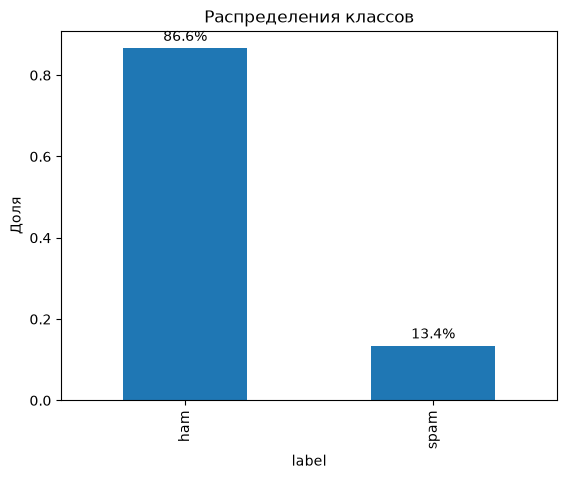

In [3]:
import pandas as pd

df = pd.read_table(f'{data_dir}/SMSSpamCollection', sep='\t', header=None, names=['label','sms_message'])

print('Размер df:', df.shape)
display(df.head(10))

counts = df['label'].value_counts(normalize=True)
ax = counts.plot(kind='bar')
ax.bar_label(ax.containers[0], labels=[f'{value:.1%}' for value in counts], padding=3)
ax.set_ylabel('Доля')
ax.set_title('Распределения классов')

Размер df_work: (5169, 2)


Text(0.5, 1.0, 'Распределения классов')

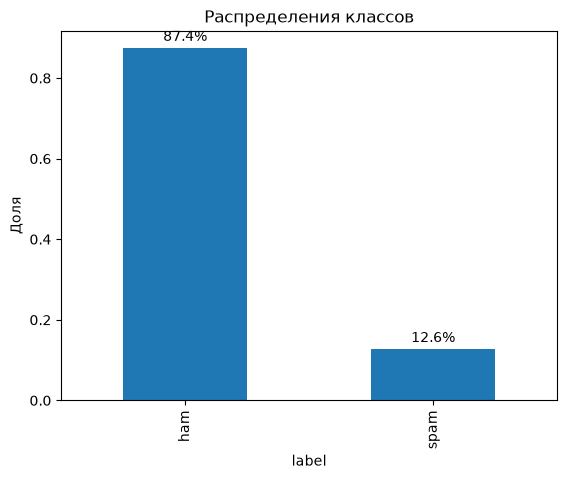

In [4]:
df_work = df.copy().drop_duplicates()
print('Размер df_work:', df_work.shape)

counts = df_work['label'].value_counts(normalize=True)
ax = counts.plot(kind='bar')
ax.bar_label(ax.containers[0], labels=[f'{value:.1%}' for value in counts], padding=3)
ax.set_ylabel('Доля')
ax.set_title('Распределения классов')

### Вывод

В датасете 5572 сообщения и есть дубликаты. До очистки классы делятся как 86.6% ham против 13.4% spam, после удаления дубликатов остаётся 5169 строк с соотношением 87.4% на 12.6%. Перекос сильный, поэтому при обучении одной accuracy будет мало: модель, которая всегда говорит "ham", уже получит около 87%, а вот спам не найдёт совсем. В текстах много шума: сокращения (u, ur, txt, pls), опечатки, капс, суммы и телефоны, а также слова-паразиты - всё это придётся учитывать при очистке.

### Шаг 2. Токенизация и базовая статистика

Выберите 3–5 предложений из датасета.

Выполните токенизацию.

Для каждого предложения посчитайте:

- количество токенов;

- количество типов;

- количество лексем.

Представьте результаты в виде таблицы.

Кратко прокомментируйте:
- чем отличаются токены, типы и лексемы;
- как нормализация влияет на представление текста.

In [5]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\wolftik\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\wolftik\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\wolftik\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\wolftik\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
lem = WordNetLemmatizer()

# беру 5 сообщений из очищенного датасета
sample_five = df_work.sample(n=5, random_state=1)
texts = sample_five['sms_message'].tolist()

results = []

for text in texts:
    tokens = word_tokenize(text)
    tokens_lower = [i.lower() for i in tokens]              # нижний регистр, чтобы Free и free были одним типом
    lemmas = [lem.lemmatize(i) for i in tokens_lower]       # нормальные формы

    n_tokens = len(tokens_lower)                            # всего слов, с повторами
    n_types = len(set(tokens_lower))                        # уникальные словоформы
    n_lemmas = len(set(lemmas))                             # уникальные леммы

    results.append((text, n_tokens, n_types, n_lemmas))

stats = pd.DataFrame(results, columns=['Текст', 'Токены', 'Типы', 'Леммы'])
display(stats)

,Текст,Токены,Типы,Леммы
0,Ok. But i finish at 6.,8,7,7
1,87077: Kick off a new season with 2wks FREE go...,27,22,22
2,Ron say fri leh. N he said ding tai feng cant ...,21,17,17
3,Do you want a new Video phone? 600 anytime any...,29,28,27
4,"I prefer my free days... Tues, wed, fri oso ca...",20,17,17


Демо: ['cats', 'saw', 'the', 'cat', 'and', 'the', 'cats', 'ran']
Токенов: 8 | типов: 6 | лемм: 5
Леммы: ['cat', 'saw', 'the', 'cat', 'and', 'the', 'cat', 'ran']


### Вывод

Токен - это каждое слово в тексте с учётом повторов, тип - уникальная словоформа, а лемма - нормальная (словарная) форма слова. На пяти коротких сообщениях типы и леммы почти не разошлись: сленговые сокращения (ur, fri, txt) лемматизатор как существительное не меняет, а разные формы одного слова внутри одного SMS встречаются редко.

### Шаг 3. Очистка текста и анализ изменений

Выполните базовую предобработку текста:

- приведение к нижнему регистру;

- удаление пунктуации;

- удаление стоп-слов;

- при необходимости — лемматизация.

Для не менее чем 100 документов посчитайте длину текста в токенах до и после очистки.

Кратко прокомментируйте:
- насколько изменилась длина текстов;
- как предобработка может повлиять на словарь признаков и обучение модели.

In [70]:
import re
import matplotlib.pyplot as plt
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()                                  # нижний регистр
    text = re.sub(r'[^a-z ]', ' ', text)                 # убираю пунктуацию, цифры и прочие символы
    tokens = word_tokenize(text)
    tokens = [i for i in tokens if i not in stop_words]  # убираю стоп-слова
    tokens = [lem.lemmatize(i) for i in tokens]          # лемматизация
    return tokens

# беру 200 документов, в задании нужно минимум 100
sample_200 = df_work.sample(n=200, random_state=42).copy()

sample_200['tokens_before'] = sample_200['sms_message'].apply(word_tokenize)
sample_200['tokens_after'] = sample_200['sms_message'].apply(clean_text)

sample_200['len_before'] = sample_200['tokens_before'].apply(len)
sample_200['len_after'] = sample_200['tokens_after'].apply(len)

Средняя длина до очистки: 19.69 токенов
Средняя длина после очистки: 9.62 токенов
Сокращение: 51.2 %
До:    ['K', ',', 'makes', 'sense', ',', 'btw', 'carlos', 'is', 'being', 'difficult', 'so', 'you', 'guys', 'are', 'gon', 'na', 'smoke', 'while', 'I', 'go', 'pick', 'up', 'the', 'second', 'batch', 'and', 'get', 'gas']
После: ['k', 'make', 'sense', 'btw', 'carlos', 'difficult', 'guy', 'gon', 'na', 'smoke', 'go', 'pick', 'second', 'batch', 'get', 'gas']


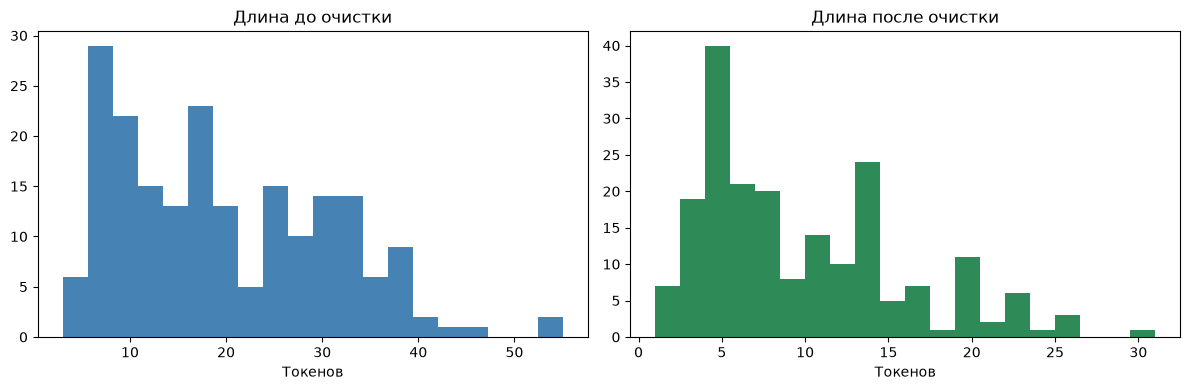

In [71]:
before_mean = sample_200['len_before'].mean()
after_mean = sample_200['len_after'].mean()

print('Средняя длина до очистки:', round(before_mean, 2), 'токенов')
print('Средняя длина после очистки:', round(after_mean, 2), 'токенов')
print('Сокращение:', round(100 * (1 - after_mean / before_mean), 1), '%')

example = sample_200['sms_message'].iloc[0]
print('До:   ', word_tokenize(example))
print('После:', clean_text(example))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(sample_200['len_before'], bins=20, color='steelblue')
ax[0].set_title('Длина до очистки')
ax[0].set_xlabel('Токенов')
ax[1].hist(sample_200['len_after'], bins=20, color='seagreen')
ax[1].set_title('Длина после очистки')
ax[1].set_xlabel('Токенов')
plt.tight_layout()
plt.show()

### Вывод

Очистка сокращает текст в среднем вдвое: с 19.69 токенов до 9.62, то есть примерно на 51%, медиана падает с 17.5 до 8. Основной вклад дают стоп-слова и удаление пунктуации, цифр и телефонных номеров. Для словаря признаков это плюс: из матрицы уходят сотни неинформативных токенов, размерность падает, и модели проще найти значимые слова. Минус в том, что вместе со стоп-словами уходит часть контекста, а сленг и сокращения (u, ur) чистка не нормализует, поэтому их приходится оставлять как есть. Лемматизация длину почти не меняет - по той же причине, что и на шаге 2.

### Шаг 4. Векторизация текста

Сформируйте корпус из 10–15 документов.

Примените к нему CountVectorizer.

Примените к тому же корпусу TF-IDF.

Для одного и того же документа покажите и сравните оба вектора.

При необходимости оформите сравнение в виде таблицы.

Кратко прокомментируйте:
- в чём разница между CountVectorizer и TF-IDF;
- какие слова получают больший вес в TF-IDF и почему;
- какой из подходов лучше подходит для вашей задачи и по какой причине.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# корпус из 12 реальных сообщений
corpus = df_work['sms_message'].sample(n=12, random_state=7).tolist()

count_vec = CountVectorizer()
X_counts = count_vec.fit_transform(corpus)

tfidf_vec = TfidfVectorizer()
X_tfidf = tfidf_vec.fit_transform(corpus)

print('Размер корпуса:', len(corpus))
print('Размер словаря:', X_counts.shape[1], 'слов')

Размер корпуса: 12
Размер словаря: 101 слов


In [ ]:
doc_index = 0
words = count_vec.get_feature_names_out()

compare = pd.DataFrame({
    'Слово': words,
    'Count': X_counts[doc_index].toarray().ravel(),
    'TF-IDF': X_tfidf[doc_index].toarray().ravel()
})

# оставлю только слова, которые есть в документе
compare = compare[compare['Count'] > 0].sort_values('TF-IDF', ascending=False)

print('Документ:', corpus[doc_index])
display(compare)
print('Сумма Count:', compare['Count'].sum())
print('Сумма TF-IDF:', round(compare['TF-IDF'].sum(), 4))

Документ: Up to ü... Ü wan come then come lor... But i din c any stripes skirt...


,Слово,Count,TF-IDF
15,come,2,0.501574
5,any,1,0.292016
11,but,1,0.292016
23,din,1,0.292016
51,lor,1,0.292016
72,skirt,1,0.292016
76,stripes,1,0.292016
80,then,1,0.292016
88,wan,1,0.250787
86,up,1,0.221534


Сумма Count: 12
Сумма TF-IDF: 3.2169


### Вывод

CountVectorizer считает просто количество вхождений слова, поэтому его вектор состоит из целых чисел, а у длинных документов значения в среднем больше. TF-IDF дополнительно делит на длину документа (TF) и умножает на редкость слова в корпусе (IDF), поэтому его вектор нормирован, а сумма весов в нашем документе получилась около 3.2 вместо 12. В выбранном сообщении слово "come" встретилось дважды и получило самый большой вес 0.50, а частое служебное "to" - только 0.20. Для классификации SMS лучше подходит TF-IDF: он гасит частые для всего корпуса слова и не даёт длинному сообщению преимущество только за счёт длины.

### Шаг 5. Обучение модели

Разделите данные на обучающую и тестовую выборки.

Преобразуйте тексты в TF-IDF-признаки.

Обучите наивный байесовский классификатор на задаче бинарной классификации.

Рассчитайте метрики качества на тестовой выборке:

- accuracy;

- precision;

- recall;

- F1-score.

Выберите 5 примеров из тестовой выборки и для каждого покажите:

- исходный текст;

- истинный класс;

- предсказанный класс;

- вероятности предсказания по классам.

Кратко прокомментируйте:
- какие тексты модель определяет уверенно;
- в каких случаях она ошибается;
- какие ограничения наивного Байеса проявились в вашей задаче.

In [74]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# кодирую метки: ham -> 0, spam -> 1
le = LabelEncoder().fit(df_work['label'])
y = le.transform(df_work['label'])

X_train, X_test, y_train, y_test = train_test_split(
    df_work['sms_message'], y, test_size=0.2, random_state=1, stratify=y
)

tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print('Обучающая выборка:', X_train_tfidf.shape)
print('Тестовая выборка:', X_test_tfidf.shape)

Обучающая выборка: (4135, 7658)
Тестовая выборка: (1034, 7658)


In [75]:
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_pred = nb.predict(X_test_tfidf)

print('Accuracy: ', round(accuracy_score(y_test, y_pred), 4))
print('Precision:', round(precision_score(y_test, y_pred), 4))
print('Recall:   ', round(recall_score(y_test, y_pred), 4))
print('F1-score: ', round(f1_score(y_test, y_pred), 4))
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy:  0.9613
Precision: 1.0
Recall:    0.6947
F1-score:  0.8198

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       903
        spam       1.00      0.69      0.82       131

    accuracy                           0.96      1034
   macro avg       0.98      0.85      0.90      1034
weighted avg       0.96      0.96      0.96      1034



In [76]:
proba = nb.predict_proba(X_test_tfidf)
test_texts = X_test.reset_index(drop=True)

# беру первые три сообщения и два примера, где модель ошиблась
errors = np.where(y_pred != y_test)[0]
examples = [0, 1, 2, errors[0], errors[1]]

for i in examples:
    print('---')
    print('Текст:', test_texts.iloc[i])
    print('Истина:', le.classes_[y_test[i]], '| Предсказание:', le.classes_[y_pred[i]])
    print('Вероятности (ham / spam):', np.round(proba[i], 4))

---
Текст: Yup i've finished c ü there...
Истина: ham | Предсказание: ham
Вероятности (ham / spam): [0.9926 0.0074]
---
Текст: I got a call from a landline number. . . I am asked to come to anna nagar . . . I will go in the afternoon
Истина: ham | Предсказание: ham
Вероятности (ham / spam): [0.9927 0.0073]
---
Текст: You do got a shitload of diamonds though
Истина: ham | Предсказание: ham
Вероятности (ham / spam): [0.9729 0.0271]
---
Текст: Bored of speed dating? Try SPEEDCHAT, txt SPEEDCHAT to 80155, if you don't like em txt SWAP and get a new chatter! Chat80155 POBox36504W45WQ 150p/msg rcd 16
Истина: spam | Предсказание: ham
Вероятности (ham / spam): [0.7285 0.2715]
---
Текст: I want some cock! My hubby's away, I need a real man 2 satisfy me. Txt WIFE to 89938 for no strings action. (Txt STOP 2 end, txt rec £1.50ea. OTBox 731 LA1 7WS. )
Истина: spam | Предсказание: ham
Вероятности (ham / spam): [0.8915 0.1085]


### Вывод

Наивный Байес дал accuracy 0.9613, precision 1.0, recall 0.6947 и F1 0.8198. Precision равен единице - модель практически не отправляет обычные сообщения в спам, зато recall низкий: примерно треть спама (около 40 из 1034 сообщений) она пропускает. Это прямое следствие дисбаланса, спама всего 12.6%, поэтому модель смещается в сторону частого класса ham. Уверенно определяются шаблонные спамы с телефоном, суммой и словами вроде "txt", "free", "claim" - вероятность спама там близка к 1. Ошибается модель на спаме, написанном разговорным языком. Ограничения наивного Байеса здесь проявились в чувствительности к дисбалансу.

### Шаг 6. Итоговые выводы

В конце работы сформулируйте не менее 5 итоговых тезисов, в которых отразите:

- как предобработка влияет на текстовые данные и признаки;

- в чём различие CountVectorizer и TF-IDF;

- как ведёт себя наивный Байес на текстовой задаче;

- какие ограничения классических моделей проявляются при работе с текстами;

- какие подходы и инструменты оказались наиболее полезными в рамках задания.

### Итог

- Предобработка сокращает сообщение почти вдвое (с 19.7 до 9.6 токенов, -51%): уходят пунктуация, цифры и стоп-слова. Словарь признаков становится меньше и чище, но вместе со стоп-словами теряется часть контекста, а сленг и сокращения (u, ur, txt) остаются нетронутыми.

- CountVectorizer даёт простые частоты слов, а TF-IDF нормирует их по длине документа и редкости слова в корпусе. Поэтому в TF-IDF частые слова вроде "to" получают маленький вес, а характерные для документа слова - большой. Для текстов разной длины TF-IDF даёт более устойчивые признаки.

- Наивный Байес на TF-IDF показал accuracy 0.9613 и F1 0.8198. Он почти не ошибается на обычных сообщениях (precision 1.0), но пропускает около 31% спама (recall 0.6947).

- Главные ограничения классических моделей в этой задаче: сильный дисбаланс классов (12.6% спама) смещает предсказания в сторону ham.

- Из инструментов больше всего пригодились TfidfVectorizer и MultinomialNB: вся связка занимает несколько строк и сразу даёт рабочее качество. Для дальнейшего роста качества стоит попробовать линейные модели вроде логистической регрессии, которые учитывают вклад каждого слова.